In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
!curl -L -o ./brain-tumor-mri-scans.zip https://www.kaggle.com/api/v1/datasets/download/rm1000/brain-tumor-mri-scans

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  236M  100  236M    0     0   130M      0  0:00:01  0:00:01 --:--:--  177M


In [ ]:
import zipfile

DATA_DIR = "./data"
ZIP_FILENAME = "./brain-tumor-mri-scans.zip"

with zipfile.ZipFile(ZIP_FILENAME) as zf:
    zf.extractall(DATA_DIR)

In [ ]:
import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support

In [ ]:
mlflow.set_tracking_uri("https://mlflow.alexchirino.online")
experiment = mlflow.set_experiment("brain-tumor-mri-classification")

In [ ]:
BATCH_SIZE = 1 << 5
EPOCHS = 5
LEARNING_RATE = 1e-3
IMAGE_SIZE = (224, 224)

transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)

total_count = len(dataset)
train_size = int(0.70 * len(dataset))
val_size = int(0.10 * len(dataset))
test_size = total_count - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size],
    generator=generator,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted")
    return acc, precision, recall, f1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
dataset.classes

['glioma', 'healthy', 'meningioma', 'pituitary']

Epoch [1/5] - Train Loss: 0.5927 | Train Acc: 0.8035 | Val Acc: 0.8917
Epoch [2/5] - Train Loss: 0.2318 | Train Acc: 0.9325 | Val Acc: 0.9359
Epoch [3/5] - Train Loss: 0.1429 | Train Acc: 0.9595 | Val Acc: 0.9544
Epoch [4/5] - Train Loss: 0.0904 | Train Acc: 0.9762 | Val Acc: 0.9630
Epoch [5/5] - Train Loss: 0.0576 | Train Acc: 0.9882 | Val Acc: 0.9672


2026/09/06 21:12:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/09/06 21:12:57 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/09/06 21:13:04 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the loca

Experimento completado. Accuracy: 0.9730 | F1-score: 0.9728
🏃 View run ResNet18_TransferLearning at: https://mlflow.alexchirino.online/#/experiments/1/runs/59d7f03737964b7e9d3fcb3bcf0f8e58
🧪 View experiment at: https://mlflow.alexchirino.online/#/experiments/1


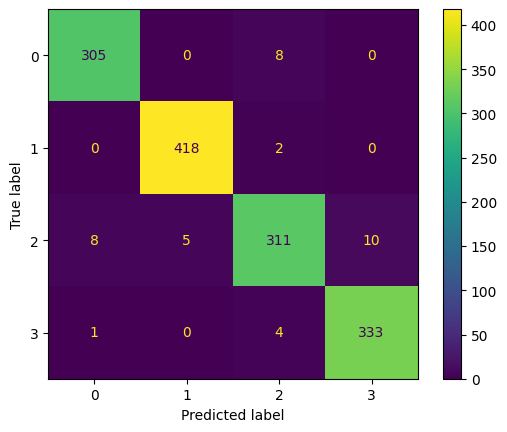

In [ ]:
EPOCHS = 5
BATCH_SIZE = 1 << 5
LEARNING_RATE = 1e-5
MODEL_NAME = "mri-resnet18-model"
RUN_NAME = "ResNet18_TransferLearning"

with mlflow.start_run(
    run_name=RUN_NAME,
    experiment_id=experiment.experiment_id,
):
    mlflow.log_param("architecture", "ResNet18")
    mlflow.log_param("pretrained", True)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("device", device)

    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(dataset.classes))
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    global_step = 0
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            mlflow.log_metric("batch_loss", loss.item(), step=global_step)
            global_step += 1

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct_train / total_train
        val_acc, val_precision, val_recall, val_f1 = evaluate_model(model, val_loader, device=device)

        mlflow.log_metric("train_loss", epoch_loss, step=epoch)
        mlflow.log_metric("train_accuracy", epoch_acc, step=epoch)
        mlflow.log_metric("val_accuracy", val_acc, step=epoch)
        mlflow.log_metric("val_f1_score", val_f1, step=epoch)

        print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Acc: {val_acc:.4f}")

    acc, precision, recall, f1 = evaluate_model(model, test_loader, device)

    with torch.no_grad():
        y_pred, y_true = [], []
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, dim=1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    cm = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    mlflow.log_metric("test_accuracy", acc)
    mlflow.log_metric("test_precision", precision)
    mlflow.log_metric("test_recall", recall)
    mlflow.log_metric("test_f1_score", f1)
    mlflow.log_figure(cm.figure_, "confusion_matrix.png")

    mlflow.pytorch.log_model(
        model,
        name=MODEL_NAME,
        serialization_format="pickle",
    )

    print(f"Experimento completado. Accuracy: {acc:.4f} | F1-score: {f1:.4f}")

Epoch [1/5] - Train Loss: 1.1866 | Train Acc: 0.6890 | Val Acc: 0.7991
Epoch [2/5] - Train Loss: 0.4556 | Train Acc: 0.8291 | Val Acc: 0.8234
Epoch [3/5] - Train Loss: 0.3101 | Train Acc: 0.8851 | Val Acc: 0.8704
Epoch [4/5] - Train Loss: 0.2214 | Train Acc: 0.9158 | Val Acc: 0.8803
Epoch [5/5] - Train Loss: 0.1706 | Train Acc: 0.9361 | Val Acc: 0.9103


2026/09/06 21:47:41 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/09/06 21:47:42 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/09/06 21:47:46 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version la

Experimento completado. Accuracy: 0.9174 | F1-score: 0.9165
🏃 View run CNN_Simple_Dropout at: https://mlflow.alexchirino.online/#/experiments/1/runs/bb31c73c91fe4f469f1832095c863219
🧪 View experiment at: https://mlflow.alexchirino.online/#/experiments/1


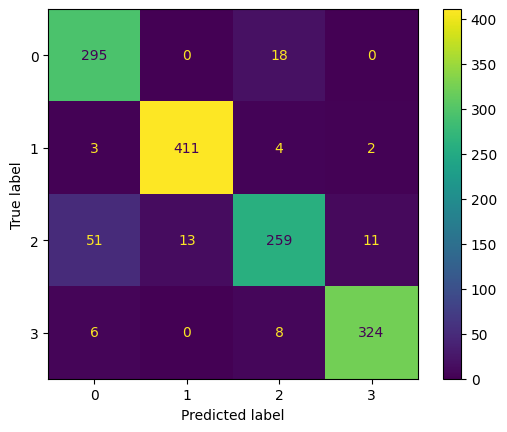

In [ ]:
EPOCHS = 5
BATCH_SIZE = 1 << 5
LEARNING_RATE = 1e-3
MODEL_NAME = "mri-cnn-simple-model"
RUN_NAME = "CNN_Simple_Dropout"
ARCHITECTURE_NAME = "ResNet18"
DROPOUT_RATE = 0.5
PRETRAINED = False


class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # (224, 224) -> (112, 112)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # (112, 112) -> (56, 56)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

with mlflow.start_run(
    run_name=RUN_NAME,
    experiment_id=experiment.experiment_id,
):
    mlflow.log_param("architecture", ARCHITECTURE_NAME)
    mlflow.log_param("pretrained", PRETRAINED)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("device", device)
    mlflow.log_param("dropout_rate", DROPOUT_RATE)

    model = SimpleCNN(num_classes=len(dataset.classes)).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    global_step = 0
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            mlflow.log_metric("batch_loss", loss.item(), step=global_step)
            global_step += 1

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct_train / total_train
        val_acc, val_precision, val_recall, val_f1 = evaluate_model(model, val_loader, device=device)

        mlflow.log_metric("train_loss", epoch_loss, step=epoch)
        mlflow.log_metric("train_accuracy", epoch_acc, step=epoch)
        mlflow.log_metric("val_accuracy", val_acc, step=epoch)
        mlflow.log_metric("val_f1_score", val_f1, step=epoch)

        print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Acc: {val_acc:.4f}")

    acc, precision, recall, f1 = evaluate_model(model, test_loader, device)

    with torch.no_grad():
        y_pred, y_true = [], []
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, dim=1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    cm = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    mlflow.log_metric("test_accuracy", acc)
    mlflow.log_metric("test_precision", precision)
    mlflow.log_metric("test_recall", recall)
    mlflow.log_metric("test_f1_score", f1)
    mlflow.log_figure(cm.figure_, "confusion_matrix.png")

    mlflow.pytorch.log_model(
        model,
        name=MODEL_NAME,
        serialization_format="pickle",
    )

    print(f"Experimento completado. Accuracy: {acc:.4f} | F1-score: {f1:.4f}")